### 6. (a) Use CNN to classify CIFAR-10 images and plot training/validation accuracy.

In [1]:
!pip install torch torchvision


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 43.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

100%|██████████| 170M/170M [00:05<00:00, 31.2MB/s]


Epoch [1/10], Loss: 1.3751, Test Accuracy: 63.26%
Epoch [2/10], Loss: 1.0080, Test Accuracy: 68.58%
Epoch [3/10], Loss: 0.8562, Test Accuracy: 70.55%
Epoch [4/10], Loss: 0.7471, Test Accuracy: 72.45%
Epoch [5/10], Loss: 0.6547, Test Accuracy: 73.94%
Epoch [6/10], Loss: 0.5785, Test Accuracy: 74.18%
Epoch [7/10], Loss: 0.5050, Test Accuracy: 74.35%
Epoch [8/10], Loss: 0.4444, Test Accuracy: 74.88%
Epoch [9/10], Loss: 0.3884, Test Accuracy: 74.53%
Epoch [10/10], Loss: 0.3435, Test Accuracy: 74.70%


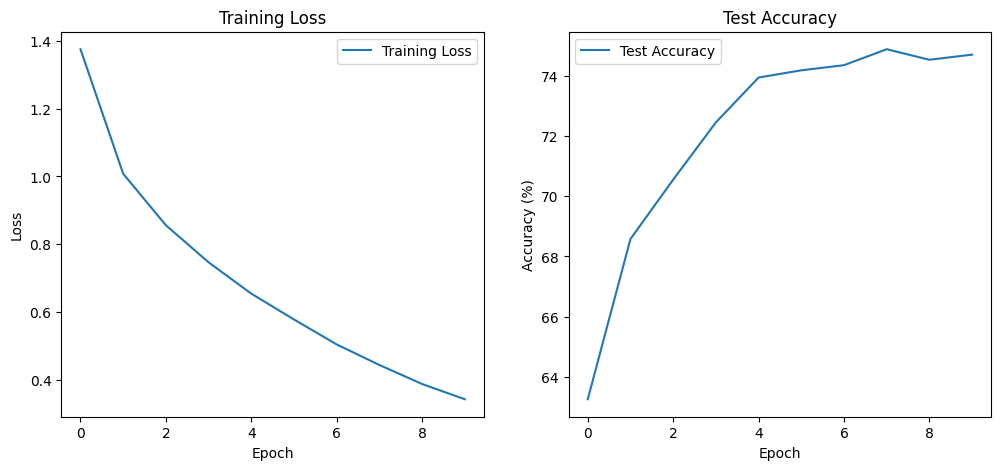

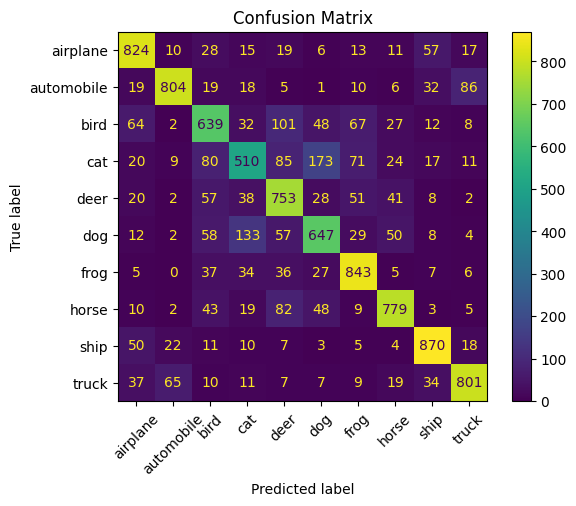

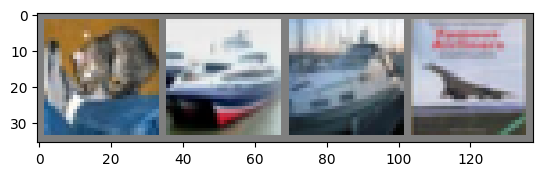

In [2]:
# Complete model training and testing
# CNN on CIFAR-10 Dataset using PyTorch

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Data Preprocessing and Loading
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                             download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                            download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

classes = ('airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

# 2. CNN Model Definition
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = CNN().to(device)

# 3. Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 4. Training the Model
train_loss_history = []
test_accuracy_history = []
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_loss_history.append(train_loss)

    # Evaluate on test set
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    test_accuracy_history.append(accuracy)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {train_loss:.4f}, Test Accuracy: {accuracy:.2f}%")

# 5. Plotting Loss and Accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss_history, label='Training Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(test_accuracy_history, label='Test Accuracy')
plt.title('Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.show()

# 6. Confusion Matrix
all_preds = []
all_labels = []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
ConfusionMatrixDisplay(cm, display_labels=classes).plot(xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

# 7. Visualizing Predictions
def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

dataiter = iter(test_loader)
images, labels = next(dataiter)

# Print images
imshow(torchvision.utils.make_grid(images[:4]))

In [3]:
# Print predicted labels
images = images.to(device)
outputs = model(images[:4])
_, predicted = torch.max(outputs, 1)

print("Predicted:", ' '.join(f'{classes[predicted[j]]}' for j in range(4)))
print("Actual:   ", ' '.join(f'{classes[labels[j]]}' for j in range(4)))

Predicted: cat ship ship ship
Actual:    cat ship ship airplane


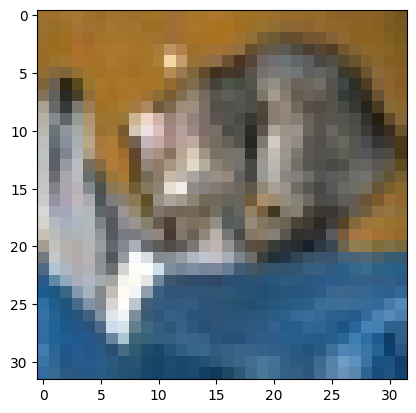

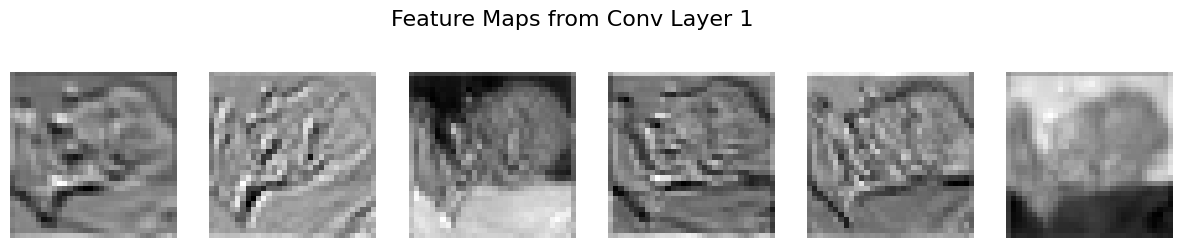

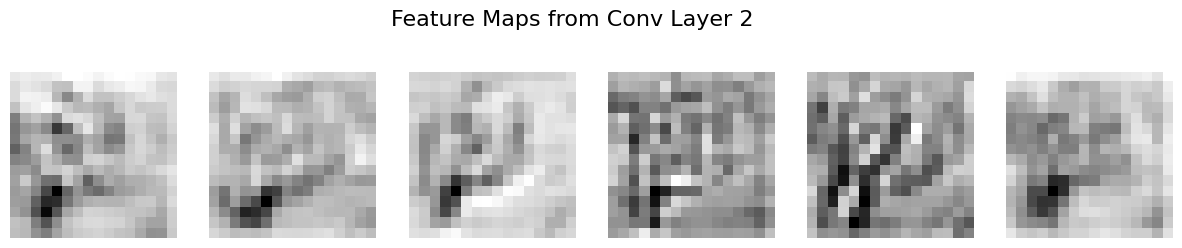

In [4]:
# 8. Visualizing Feature Maps from Convolutional Layers

def visualize_feature_maps(model, image, layer_names):
    """
    Pass a single image through the model and plot feature maps from selected layers.
    """
    model.eval()
    x = image.unsqueeze(0).to(device)  # add batch dimension
    outputs = []

    # Hook to extract outputs from each conv layer
    def hook_fn(module, input, output):
        outputs.append(output)

    hooks = []
    for name, layer in model.features._modules.items():
        if isinstance(layer, nn.Conv2d):
            hooks.append(layer.register_forward_hook(hook_fn))

    # Forward pass
    with torch.no_grad():
        model(x)

    # Remove hooks
    for hook in hooks:
        hook.remove()

    # Plot feature maps
    for idx, feature_map in enumerate(outputs):
        fmap = feature_map.squeeze(0).cpu()
        num_channels = min(6, fmap.shape[0])  # show up to 6 channels
        fig, axs = plt.subplots(1, num_channels, figsize=(15, 3))
        fig.suptitle(f'Feature Maps from Conv Layer {idx + 1}', fontsize=16)
        for i in range(num_channels):
            axs[i].imshow(fmap[i], cmap='gray')
            axs[i].axis('off')
        plt.show()


# Get one image from test set
sample_image, sample_label = test_dataset[0]
imshow(sample_image)  # visualize input image

# Visualize feature maps
visualize_feature_maps(model, sample_image, layer_names=["Conv1", "Conv2"])
